In [1]:
# (ch12_env) PS C:\Aiprojects\ch12\ch12-2> deactivate
# PS C:\Aiprojects\ch12\ch12-2> cd..
# PS C:\Aiprojects\ch12> cd..
# PS C:\Aiprojects> python -m venv ch13_env
# PS C:\Aiprojects> ch13_env\Scripts\Activate
# (ch13_env) PS C:\Aiprojects> python -m pip install --upgrade pip
# pip uninstall langchain-openai openai -y
# pip install langchain==0.2.14 langchain-community==0.2.12 langchain-openai==0.1.22 langgraph==0.2.16 openai==1.40.0 chromadb==0.5.5 tiktoken==0.7.0 pydantic==2.7.4 python-dotenv==1.0.1 langchain-chroma==0.1.2 httpx==0.27.0 pypdf

# 주피터 노트북 파일 rag_with_langgraph.ipynb을 만들고 RAG에 필요한 요소들을 하나
# 씩 채워 가겠습니다. 09장에서 사용한 PDF 파일들을 사용하겠습니다. 09장에서 사용한
# data 폴더를 프로젝트 폴더에 붙여 넣고 다음처럼 입력해 PDF 파일들이 잘 있는지 확인해 봅
# 시다.

from glob import glob 

for g in glob('../data/*.pdf'):
    print(g)

../data\2040_seoul_plan.pdf
../data\OneNYC_2050_Strategic_Plan.pdf


In [2]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

def read_pdf_and_split_text(pdf_path, chunk_size=1000, chunk_overlap=100):
    """
    주어진 PDF 파일을 읽고 텍스트를 분할합니다.
    매개변수:
        pdf_path (str): PDF 파일의 경로.
        chunk_size (int, 선택적): 각 텍스트 청크의 크기. 기본값은 1000입니다.
        chunk_overlap (int, 선택적): 청크 간의 중첩 크기. 기본값은 100입니다.
    반환값:
        list: 분할된 텍스트 청크의 리스트.
    """
    print(f"PDF: {pdf_path} -----------------------------")

    pdf_loader = PyPDFLoader(pdf_path)
    data_from_pdf = pdf_loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap
    )

    splits = text_splitter.split_documents(data_from_pdf)
    
    print(f"Number of splits: {len(splits)}\n")
    return splits

In [ ]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma # pip install langchain-chroma==0.1.2
import os

##### Vectorstore 설정 #####
embedding = OpenAIEmbeddings(model='text-embedding-3-large')

persist_directory='../chroma_store'

if os.path.exists(persist_directory):
    print("Loading existing Chroma store")
    vectorstore = Chroma(
        persist_directory=persist_directory, 
        embedding_function=embedding
    )
else:
    print("Creating new Chroma store")
    
    vectorstore = None
    for g in glob('../data/*.pdf'):
        chunks = read_pdf_and_split_text(g)
        # 100개씩 나눠서 저장
        for i in range(0, len(chunks), 100):
            if vectorstore is None:
                vectorstore = Chroma.from_documents(
                    documents=chunks[i:i+100],
                    embedding=embedding,
                    persist_directory=persist_directory
                )
            else:
                vectorstore.add_documents(
                    documents=chunks[i:i+100]
                )
# 앞서 만든 read_pdf_and_split_text 함수를 이용해 잘라 놓은 청크들을 임베딩해서 크로마
# DB에 저장하겠습니다. 임베딩하는 비용과 시간을 절약하고 싶다면 09장에서 만든 chroma
# store 폴더를 현재 실습 폴더로 복사하면 됩니다. 이미 크로마 DB로 만든 벡터 DB가 chroma
# store 폴더에 저장되어 있는 경우에는 그 DB를 읽어 vectorstore에 담습니다.

Creating new Chroma store
PDF: ../data\2040_seoul_plan.pdf -----------------------------
Number of splits: 308



Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


PDF: ../data\OneNYC_2050_Strategic_Plan.pdf -----------------------------
Number of splits: 1023



In [ ]:
# 이제 벡터 DB가 잘 작동하는지 확인해 봅시다. 이 실습에서 사용한 PDF 파일은 서울, 뉴
# 욕의 도시 계획에 관한 문서이므로 '서울 온실가스 저감 계획'이라는 쿼리를 사용해 관련 문
# 서를 가져오도록 테스트했습니다.
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

chunks = retriever.invoke("서울 온실가스 저감 계획")

for chunk in chunks:
    print(chunk.metadata)
    print(chunk.page_content)

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


{'page': 63, 'source': '../data\\2040_seoul_plan.pdf'}
56제2장 미래상과 목표
6. 미래위기를 준비하는, ‘탄소중립 안전도시 구축’1) 배경전(全) 지구적인 기후변화에 대응하기 위한 대도시 차원의 대응 필요Ÿ서울시 2017년 온실가스 배출량은 46,685천 톤CO2eq로 2005년 배출량에 비해 5.6%(276만 톤CO2eq) 감소하였으며, 서울의 1인당 온실가스 배출량은 4.7CO2eq로 국가의 13.8톤CO2eq에 비해 낮은 수준이다. 또한 2014년 기준 서울의 1인당 온실가스 배출량은 4.5CO2eq로 세계 주요 도시에 비해 낮은 수준을 보인다.7)
[그림 2-26] 세계 주요 도시 1인당 온실가스 배출량   자료: World Bank, 2014Ÿ그럼에도 불구하고, 기후변화 문제는 21세기에 전 지구적으로 가장 위중한 영향을 미칠 것으로 예상되는바, 탄소중립과 기후위기 대응은 국제·국가·도시의 핵심 정책으로 다루어져야 한다.Ÿ파리협정(2015) 이후, 우리나라를 비롯한 미국, 유럽연합 등 세계 136개국이 탄소중립을 선언하였으며, 서울시를 비롯한 뉴욕, 런던 등과 같은 많은 글로벌 도시에서 탄소중립을 시정의 핵심과제로 추진 중이다.Ÿ우리나라는 2020년 ‘한국판 그린뉴딜’을 발표하며 공식적으로 2050 탄소중립을 선언하였으며 서울시 역시 2020년 ‘그린뉴딜 추진을 통한 2050 온실가스 감축 전략’을 발표하고 탄소중립 선언에 따른 부문별 사업을 적극 추진하고 있다.-서울시는 2050년 탄소중립을 목표로 2030년까지 2005년 배출량 대비 40%, 2040년까지 70% 감축목표를 제시하였고, 2022년 기후변화대응종합계획을 수립하여, 향후 5년간(’22~’26년) 2005년 대비 온실가스 30% 감축목표와 구체적인 실행계획을 수립하였음7) 황인창 외, 2020, 파리협정 이행 위한 서울시 ‘2050 탄소중립’ 전략, 서울연구원, pp.6-9.
{'page': 45, 'source': '../data\\204

In [5]:
from langchain_openai import ChatOpenAI

# 모델 초기화
model = ChatOpenAI(model="gpt-4o-mini")
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a7190374f3', 'finish_reason': 'stop', 'logprobs': None}, id='run-d7ed36b8-a992-474e-928c-733f5f93d1af-0', usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20})

In [ ]:
# Router 알아보기
# 사용자의 질문에 따라 RAG 사용 여부를 판단하는 기능인 라우터를 알아보고, 이를 13-1절에서 만든 챗봇에 설정해 보겠습니다.

# 라우터
# 지금 만드는 챗봇은 사용자의 질문에 따라 RAG의 사용 여부를 판단해야 합니다. 
# 예를 들어 사용자가 '잘 지냈어?'라고 입력하면 일상적인 대화를 하고, '서울시의 온실가스 저감 계획은 뭐야?'와 같은 질문을 하면 관련 문서를 활용해 RAG를 실행해야 합니다.
# 이렇게 하지 않으면 사용자가 단순한 인사말을 할 때도 불필요하게 문서를 검색해서 토큰을 낭비하고 그 내용을 대화 내용에 포함시켜 불필요한 말을 답변에 추가할 수 있으니까요.
# 이런 판단을 처리하려면 라우터router 기능이 필요합니다. 라우터는 입력한 내용에 따라 여러개의 실행 경로 중에서 적절한 경로를 결정해 다음 노드를 선택하는 기능을 합니다. 
# 일반적으로 언어 모델의 응답이나 특정 조건에 따라 다르게 동작해야 할 때 라우터를 사용합니다.

# 챗봇에 라우터 설정하기
# GPT와 같은 언어 모델이 사용자의 입력을 일상적인 대화인지 RAG가 필요한 질문인지 판단 하는 기능을 구현해 보겠습니다. 
# 일상적인 대화라면 casual_talk를 반환하고 RAG가 필요하면 vector_store를 반환합니다. 
# 그리고 이 판단에 따라 conditional_edge를 이용해 어떤 노드를 활용할지를 판단하게 됩니다. 
# 바로 앞 실습에서 사용한 주피터 노트북 파일에 이어서 작성하겠습니다.

# 랭체인을 처음 배울 때 다뤘던 BaseModel을 이용해 RouteQuery라는 클래스를 만듭니다.
# datasource 필드는 Literal 타입으로 설정하여 vector_store와 casual_talk 중 하나만 선택하도록 제한합니다. 
# 단순히 GPT에게 프롬프트로 상황에 따라 판단하고 vector_store 혹은 casual_talk 중 하나를 답변하게 할 수도 있지만 그렇게 하면 'vector_store입니다.'
# 와 같은 불필요한 내용을 답변에 포함시킬 수 있습니다.

from langchain_core.prompts import ChatPromptTemplate
from typing import Literal # 문자열 리터럴 타입을 지원하는 typing 모듈의 클래스
from pydantic import BaseModel, Field

# Data model
class RouteQuery(BaseModel):
    """사용자 쿼리를 가장 관련성이 높은 데이터 소스로 라우팅합니다."""
    
    datasource: Literal["vectorstore", "casual_talk"] = Field(
        ...,
        description="""
        사용자 질문에 따라 casual_talk 또는 vectorstore로 라우팅합니다.
        - casual_talk: 일상 대화를 위한 데이터 소스. 사용자가 일상적인 질문을 할 때 사용합니다.
        - vectorstore: 사용자 질문에 답하기 위해 RAG로 vectorstore 검색이 필요한 경우 사용합니다.
        """,
    )

In [7]:
# RouterQuery는 model.with_structured_output(RouterQuery)로 정의하여 둘 중 하나만 출력되도록 합니다. 
# router_system으로 시스템 프롬프트를 작성해 사용자의 질문을 판단 하게 합니다. 
# ChatPromptTemplate. from_messages를 이용해 route_prompt로 프롬프트 템플릿을 생성합니다. 
# 이 프롬프트 안의 "{question}"은 question_router 체인을 통해 사용자의 질문을 받는 빈칸입니다.

# 특정 모델을 structured output (구조화된 출력)과 함께 사용하기 위해 설정
structured_llm_router = model.with_structured_output(RouteQuery)

router_system = """
당신은 사용자의 질문을 vectorstore 또는 casual_talk으로 라우팅하는 전문가입니다.
- vectorstore에는 서울, 뉴욕의 발전계획과 관련된 문서가 포함되어 있습니다. 이 주제에 대한 질문에는 vectorstore를 사용하십시오.
- 사용자의 질문이 일상 대화에 관련된 경우 casual_talk을 사용하십시오.
"""

# 시스템 메시지와 사용자의 질문을 포함하는 프롬프트 템플릿 생성
route_prompt = ChatPromptTemplate.from_messages([
    ("system", router_system),
    ("human", "{question}"),
])

# 라우터 프롬프트와 구조화된 출력 모델을 결합한 객체
question_router = route_prompt | structured_llm_router

In [8]:
print(
    question_router.invoke({
        "question": "서울 온실가스 저감 계획은 무엇인가요?"
    })
)

print(question_router.invoke({"question": "잘 지냈어?"}))

datasource='vectorstore'
datasource='casual_talk'


In [9]:
# 랭그래프로 RAG 에이전트 만들;
# 여러 기능을 각각의 노드로 만들고 이 노드들을 연결하여 사용자의 요청에 대응할 수 있는 AI에이전트로 발전시켜 봅시다.

# 관련 있는 청크만 필터링하기
# 리트리버가 잘 작동하는지는 13-1절에서 이미 테스트했습니다. 리트리버는 벡터 DB에서 벡터 유사도를 기준으로 가장 관련 있는 문서 n개(현재는 5개)를 가져옵니다. 
# 문서를 무조건 5개 가져오기 때문에 질문과 관련 없는 청크가 선택될 수 있습니다. 
# 질문과 관련 없는 청크를 포함하는 경우 답변을 생성할 때 혼란을 일으킬 수 있으므로 미리 삭제하는 편이 좋습니다.
# 문서의 관련성을 판단하는 방법을 프롬프트로 작성하고, 판단 결과는 BaseModel과 .with_structured_output을 활용해 출력 형식을 제한해 보겠습니다. 
# 앞에서 사용한 주피터 노트북 파일에 이어서 작성하세요.

# BaseModel을 사용해 출력 방식을 yes 또는 no로만 제한하는 GradeDocuments 클래스를 만듭니다. 
# GPT 모델을 그대로 쓰지 않고 .with_structured_output을 사용해 출력 형식을 제한한 structured_llm_grader를 만들어서 사용합니다.

from langchain_core.prompts import PromptTemplate

class GradeDocuments(BaseModel):
    """검색된 문서가 질문과 관련성 있는지 yes 또는 no로 평가합니다."""

    binary_score: Literal["yes", "no"] = Field(
        description="문서가 질문과 관련이 있는지 여부를 'yes' 또는 'no'로 평가합니다."
    )

structured_llm_grader = model.with_structured_output(GradeDocuments)

In [10]:
# 이번에는 PromptTemplate을 이용해 프롭프트를 생성하겠습니다. 
# 이전까지는 챗봇에서 많이 사용하는 ChatPromptTemplate을 주로 활용했는데 기존 대화 내용이 계속 이어질 필요가 없는 경우에는 PromptTemplate이 더 적합합니다.

# PromptTemplate.from_template으로 프롬프트 메시지를 작성합니다. 리트리버가 가져온 청크가 질문과 관계 있으면 yes 아니면 no로 평가하도록 설정합니다. 
# 그리고 {document}, {question}으로 빈칸을 만듭니다. 이 빈칸은 for 문 안에서 딕셔너리 형태로 채워집니다. 
# 테스트를 위해 '서울시 자율주행 관련 계획'이라는 쿼리로 리트리버를 실행했습니다.
grader_prompt = PromptTemplate.from_template("""
당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 평가자입니다. \n 
문서에 사용자 질문과 관련된 키워드 또는 의미가 포함되어 있으면, 해당 문서를 관련성이 있다고 평가하십시오. \n
엄격한 테스트가 필요하지 않습니다. 목표는 잘못된 검색 결과를 걸러내는 것입니다. \n
문서가 질문과 관련이 있는지 여부를 나타내기 위해 'yes' 또는 'no'로 이진 점수를 부여하십시오.
                                             
Retrieved document: \n {document} \n\n 
User question: {question}
""")

retrieval_grader = grader_prompt | structured_llm_grader
question = "서울시 자율주행 관련 계획"
documents = retriever.invoke(question)

for doc in documents:
    print(doc)


page_content='54제2장 미래상과 목표
5. 기술발전에 선제적 대응, ‘미래교통 인프라 구축’1) 배경미래교통수단 도입에 따른 도시 활동 변화 및 공간구조 재편 대비Ÿ빠르게 진화하는 미래 신 교통수단은 도시공간에 새로운 변화를 일으킬 것이며, 도시 내 이동패턴의 변화를 가져올 것으로 예측된다. 이러한 점을 고려하여 도시 내 다양한 통행행태가 공존하는 포용적인 교통체계 구축을 준비해야 한다.미래교통수단 정착을 위한 도시 인프라 확충지원 필요Ÿ기존에 없던 새로운 교통은 통상 인프라 구축에 많은 시간이 소요되기 때문에 교통수단이 도입된 이후에 준비하기보다는 개발단계에서부터 이를 지원하기 위한 교통인프라 구축 구상이 요구되며, 새로운 도시 인프라 확충에 대한 도시계획적 지원이 필요하다.2) 추진전략자율주행 자동차 본격 운영 체계 구축Ÿ자율주행은 현재 제일 가시화되고 있는 미래 교통기술로 시장의 주도권을 확보하기 위해 각국의 노력이 집중되고 있다. 단계적으로 2030년까지 간선도로급 이상 도로에서 운영할 수 있는 도로 인프라 환경을 조성하고, 2040년까지 서울 전역 자율주행 운행 환경 구축을 목표로 한다.-2040년까지 서울 전역 자율주행차량의 운행 환경을 구축하고 수송 분담률 10%를 달성서울형 도심 항공교통 기반 마련 및 터미널 확충Ÿ도심에서 김포공항까지 시범노선을 운영하는 등 상용화 노선을 확보하고, 장기적으로 한강, 지천 등 주요 수변 공간 중심으로 광역노선을 확보한다. 또한 UAM 인프라 확보를 위한 인센티브 및 도시계획적인 지원 방안도 함께 검토한다.-UAM 시범노선을 운영하고, 한강 등 주요 수변 공간 중심에 단계적 광역노선을 확장서울 전역에 모빌리티 허브 구축Ÿ도심 및 광역거점에 서울 내부와 외부의 연계를 위한 미래 교통과 기존 교통을 연결하는 시설을 도입한다. 또한 교통뿐 아니라 공공서비스, 물류, 상업 등 다양한 기능들이 복합적으로 제공되는 지역 거점 모빌리티 허브를 서울 전역에 도입한다.' metadata={'page': 61, 'sou

In [ ]:
# 가져온 청크 중 '서울시 자율주행 계획'과 관련된 문서만 찾아서 filtered_docs에 담습니다. 
# 각 청크는 retrieval_grader로 연관성을 판단하여 결과를 받아 is_relevant에 담습니다. 
# 결과가 yes인 경우에만 해당 청크가 filtered_docs 리스트에 추가됩니다.

filtered_docs = []

for i, doc in enumerate(documents):
    print(f"Document {i + 1}:")
    is_relevant = retrieval_grader.invoke({"question": question, "document": doc.page_content})
    print(is_relevant)
    print(doc.page_content[:200])
    print("=================================\n\n")

    if is_relevant.binary_score == "yes":
        filtered_docs.append(doc)

print(f"Filtered documents: {len(filtered_docs)}")

# 이 셀을 실행해 보니 다음과 같은 결과가 나옵니다. 서울시 자율주행 관련 내용을 5개 검색했지만, 관련 있는 내용은 3개뿐이었습니다. 
# 언어 모델이 판단한 것이므로 반드시 3개가 아닐수도 있어 리트리버로 가져온 문서를 살펴보니 판단을 잘 내렸습니다.

Document 1:
binary_score='yes'
54제2장 미래상과 목표
5. 기술발전에 선제적 대응, ‘미래교통 인프라 구축’1) 배경미래교통수단 도입에 따른 도시 활동 변화 및 공간구조 재편 대비Ÿ빠르게 진화하는 미래 신 교통수단은 도시공간에 새로운 변화를 일으킬 것이며, 도시 내 이동패턴의 변화를 가져올 것으로 예측된다. 이러한 점을 고려하여 도시 내 다양한 통행행태가 공존하는 포용적인 교통체계 구


Document 2:
binary_score='yes'
36제2장 미래상과 목표
6) 미래교통수단의 등장과 첨단 인프라 요구 증대자율주행, UAM 등 미래 교통에 공간적 대응방안 마련 필요Ÿ자율주행차량, 전동킥보드 등 교통 기술의 발전에 따라 새로운 교통환경이 조성되고 있음에도 불구하고, 이에 대한 정착 가이드라인이 없어, 위험한 교통 사고가 유발되고 있다.-최근 3년간 서울시에서 발생한 전동킥보드 관련 사고 


Document 3:
binary_score='no'
제1절 도시공간구조105기능이 공존하는 미래 도심으로 조성-국제 디지털 금융중심지인 여의도·영등포는 한강을 중심으로 한 글로벌 혁신코어 조성-국제 업무 중심지인 강남은 영동대로와 경부간선도로의 입체복합화로 가용지를 확보하여 업무복합기능을 강화 Ÿ수도 서울의 위상 강화를 위해 “광화문~용산~영등포”축을 국가중심공간으로 조성한다.-북악산~청와대~광화문광장~서울


Document 4:
binary_score='yes'
광화문·시청역을, GTX-B 노선은 종로3가역 또는 동대문역 신설 제안을 검토Ÿ자전거를 비롯하여 개인용 이동수단(PM), 수상교통, 도심항공교통(UAM) 등 신 이동수단으로 도심 간 연결 수단을 다양화하고, 교통수단 상용화에 필요한 인프라를 구축한다.-여의도~잠실종합운동장, 남산공원~용산공원~용산역(정비창)~여의도 등을 연결하는 신 이동수단의 인프라 신설을


Document 5:
binary_score='yes'
제1절 도시공간구조1073) 7광역중심광역 경제권의 일자리 및

In [12]:
# RAG 답변 생성하기

# GPT로 질문 내용과 관련된 청크들만 필터링하여 남겼으니 이제 답변을 생성할 차례입니다.

# 앞서 사용한 방식과 동일하게 PromptTemplate을 이용해 사용자의 질문(question)과 관련 청크(context)를 제공했을 때 답변하는 프롬프트 rag_prompt를 만들겠습니다. 
# 같은 PromptTemplate을 사용했지만 이번에는 선언하는 방식이 달라졌습니다. 
# 앞에서는 PromptTemplate에서 from_template()을 만들고 프롬프트 텍스트와 빈칸을 써놓았지만 
# 이번에는 input_variables를 리스트로 따로 써두고 template에 rag_generate_system으로 만들어 놓은 문자열을 받도록 합니다.
# 사용자의 질문은 '서울시 자율주행 관련 계획'이고 언어 모델에게 전달할 context는 filtered_docs입니다. 이 필터링된 리스트에는 3개의 청크만 포함되어 있습니다.
### Generate
# PromptTemplate을 사용하여 RAG를 위한 프롬프트를 생성합니다.

rag_generate_system = """
너는 사용자의 질문에 대해 주어진 context에 기반하여 답변하는 도시 계획 전문가이다. 
주어진 context는 vectorstore에서 검색된 결과이다. 
주어진 context를 기반으로 사용자의 question에 대해 답변하라.

=================================
question: {question}
context: {context}
"""

# PromptTemplate을 생성하여 question과 context를 포맷팅
rag_prompt = PromptTemplate(
    input_variables=["question", "context"],
    template=rag_generate_system
)

# rag chain
rag_chain = rag_prompt | model 

# 사용자 질문과 검색된 문서를 입력으로 사용하여 RAG를 실행
question = "서울시 자율주행 관련 계획"

rag_chain.invoke({"question": question, "context": filtered_docs})


AIMessage(content='서울시는 자율주행 관련하여 여러 계획과 목표를 설정하고 있습니다. 주요 내용은 다음과 같습니다:\n\n1. **자율주행 자동차 운영 체계 구축**: 서울시는 2030년까지 간선도로급 이상의 도로에서 자율주행 차량이 운영될 수 있는 도로 인프라 환경을 조성하고, 2040년까지 서울 전역에서 자율주행 운행 환경을 구축하는 것을 목표로 하고 있습니다. 이 과정에서 자율주행차량의 수송 분담률을 10%로 달성하려고 합니다.\n\n2. **도심 항공교통(UAM) 기반 마련**: 서울시는 김포공항과 도심을 연결하는 시범 노선을 운영하고, 장기적으로는 한강과 주요 수변 공간 중심으로 광역 노선을 확충할 계획입니다. UAM 인프라 확보를 위한 인센티브와 도시계획적인 지원 방안도 검토하고 있습니다.\n\n3. **모빌리티 허브 구축**: 도심과 광역 거점에 미래 교통과 기존 교통을 연결하는 모빌리티 허브를 도입하여 공공서비스, 물류, 상업 등 다양한 기능을 복합적으로 제공하는 지역 거점을 서울 전역에 구축할 예정입니다.\n\n4. **안전한 교통환경 조성**: 자율주행차량 및 전동킥보드 등 새로운 교통수단의 도입에 따른 위험 요소를 고려하여, 안전하고 효율적인 교통수단의 조화를 도모하고, 통합적인 교통수단 정착 가이드라인을 마련할 필요성이 강조되고 있습니다.\n\n이러한 계획들은 서울시가 미래 교통 기술에 선제적으로 대응하고, 안전하고 효율적인 교통 체계를 구축하기 위한 노력의 일환으로 볼 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 398, 'prompt_tokens': 2075, 'total_tokens': 2473, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasonin

In [ ]:
# 그래프 정의하기
# 이제 RAG 에이전트에 필요한 기능을 다 만들었으니 이 기능들을 엮어서 하나의 그래프로 만들어 보겠습니다.

# 앞서 배웠듯이 TypedDict를 이용해 랭그래프에서 사용할 상태를 선언합니다. GraphState 에 필요한 정보를 담아 놓고 사용합니다. 
# 사용자 질문을 담아 두는 question, 언어 모델 답변 생성 결과를 담는 generation, 리트리버에서 검색된 문서(청크)를 담아 놓는 documents로 구성합니다. 
# 이 중 documents는 리트리버에서 문서를 가져온 후 관련성을 판단하여 최종 필터링 한 결과를 담게 됩니다.

# 앞서 테스트한 기능을 랭그래프의 노드로 구현하기 위해 함수로 만들어 보겠습니다.

# route_question 함수를 만듭니다. 이 함수는 state 매개변수를 받고 질문 내용을 바탕으로 RAG가 필요하면 vector_store를, 일반 대화 내용이면 casual_talk를 반환합니다.

from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    question: str   # 사용자 질문
    generation: str # LLM 생성 결과
    documents: List[str] # 검색된 문서

# 앞서 테스트한 기능을 랭그래프의 노드로 구현하기 위해 함수로 만들어 보겠습니다.

In [14]:
# route_question 함수를 만듭니다. 이 함수는 state 매개변수를 받고 질문 내용을 바탕으로 RAG가 필요하면 vector_store를, 일반 대화 내용이면 casual_talk를 반환합니다.
def route_question(state): 
    """
    사용자 질문을 vectorstore 또는 casual_talk로 라우팅합니다.
    
    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 라우팅된 데이터 소스와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------ROUTE------')
    question = state['question']
    route = question_router.invoke({"question": question})

    
    print(f"---Routing to {route.datasource}---")
    return route.datasource   

In [15]:
# 다음은 retrieve 노드를 정의합니다. 이 노드는 리트리버에서 state의 question으로 검색을 합니다. 
# 그 검색된 결과를 딕셔너리 형태로 반환하여 graph state를 업데이트합니다.

def retrieve(state): 
    """
    vectorstore에서 질문에 대한 문서를 검색합니다.
    
    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 검색된 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------RETRIEVE------')
    question = state['question']

    # Retrieve documents
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [16]:
# retrieve 노드에서 업데이트된 state의 documents 중에서 question과 연관성이 있는 문서만 필터링하여 
# filtered_docs에 담고 state의 documents를 filtered_docs로 업데이트하는 grade_documents 노드를 구현합니다.
def grade_documents(state):
    """
    검색된 문서를 평가하여 질문과 관련성이 있는지 확인합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 관련성이 있는 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------GRADE------')
    question = state['question']
    documents = state['documents']
    filtered_docs = []

    for i, doc in enumerate(documents):
        is_relevant = retrieval_grader.invoke({"question": question, "document": doc.page_content})
        if is_relevant.binary_score == "yes":
            filtered_docs.append(doc)
    return {"documents": filtered_docs, "question": question}  


In [17]:
# 다음으로 generate 노드를 정의합니다. 이 노드는 앞 단계의 grade_documents 노드에서 필터링한 state의 documents를 이용해 최종 답변을 생성하는 역할입니다.
def generate(state):
    """
    LLM을 사용하여 문서와 사용자 질문에 대한 답변을 생성합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): LLM 생성 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------GENERATE------')
    question = state['question']
    documents = state['documents']
    generation = rag_chain.invoke({"question": question, "context": documents})
    return {
        "documents": documents,
        "question": question,
        "generation": generation
    }

In [18]:
# RAG가 필요 없는 일상적인 질문에 답하는 casual_talk 노드를 만든다.
def casual_talk(state):
    """
    일상 대화를 위한 답변을 생성합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 일상 대화 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------CASUAL TALK------')
    question = state['question']
    generation = model.invoke(question)
    return {
        "question": question,
        "generation": generation
    }

In [19]:
# 랭그래프를 사용하려면 StateGraph를 만들고 노드들을 등록한 후, 각 노드들의 연결 관계를 정의해야 합니다. 
# 앞에서 만든 노드들을 등록할 StateGraph를 만들어 보겠습니다.

from langgraph.graph import START, StateGraph, END

workflow = StateGraph(GraphState)

In [20]:
# 노드를 정의 
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("casual_talk", casual_talk)

In [ ]:
# 그 노드들올 .add_edge로 연결합니다. 그리고 조건에 따라 경로를 선택하는 기능을 제공하는 ·add_conditional_edges 메서드를 사용합니다. 
# 이전에 만든 route_question은 질문내용에 답변하는데 RAG가 필요하면 vectorstore를, 일반 대화 내용이면 casual_talk를 반환하도록 되어 있습니다. 
# 그 결과가 어떻게 되는지에 따라 그래프의 경로가 결정됩니다. 만약 반환값이 vectorstore면 retrieve 노드로, casual_talk면 casual_talk 노드로 진행합니다.

# casual_talk 노드로 진행되면 답변을 생성하고 바로 END 노드를 만나고, retrieve 노드로 진행되면 retrieve → grade_documents → generate → END 경로로 연결됩니다. 
# 이 그래프를 app이라는 이름으로 컴파일합니다.


In [21]:
# graph를 정의
workflow.add_conditional_edges(
    START, 
    route_question,
    {
        "vectorstore": "retrieve",
        "casual_talk": "casual_talk"
    }
)
workflow.add_edge("casual_talk", END)
workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("grade_documents", "generate")
workflow.add_edge("generate", END)

app = workflow.compile() # workflow를 컴파일

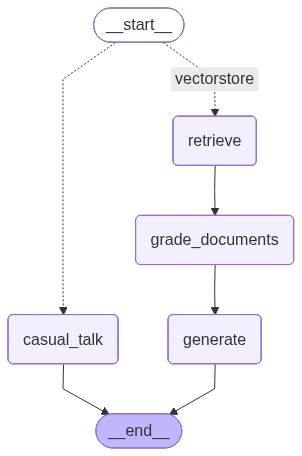

In [23]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    #  실패 시 통과
    pass

In [24]:
# 테스트 해보기
inputs = {
    "question": "서울시 자율주행 계획"
}

app.invoke(inputs) # workflow를 실행합니다.

------ROUTE------
---Routing to vectorstore---
------RETRIEVE------
------GRADE------
------GENERATE------


{'question': '서울시 자율주행 계획',
 'generation': AIMessage(content='서울시는 자율주행 자동차와 관련된 미래 교통 계획을 적극적으로 추진하고 있습니다. 2030년까지 간선도로급 이상 도로에서 자율주행 차량이 운영될 수 있는 인프라 환경을 조성하고, 2040년까지는 서울 전역에서 자율주행 차량의 운행을 위한 환경을 구축하는 것을 목표로 하고 있습니다. 이 과정에서 자율주행 차량의 수송 분담률을 10%로 달성하는 것을 계획하고 있습니다.\n\n또한, 서울시는 도심 항공교통(UAM) 기반을 마련하고, 주요 수변 공간에 광역노선을 확보하는 등의 조치를 취하고 있습니다. 이를 통해 서울 내부와 외부의 교통을 연결하는 모빌리티 허브를 도입하여, 다양한 기능이 복합적으로 제공되는 지역 거점을 구축할 계획입니다.\n\n이와 함께, 자율주행 기술의 발전에 따라 새로운 교통환경이 조성되고 있지만, 이에 대한 안전하고 효율적인 정착 가이드라인이 필요하다는 점도 강조하고 있습니다. 이를 통해 자율주행 차량과 기존 교통수단 간의 조화를 도모하고, 안전한 교통환경을 조성하는 것이 필요합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 266, 'prompt_tokens': 1894, 'total_tokens': 2160, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_21e7b37e61'

In [25]:
inputs = {
    "question": "잘 지내고 있어?"
}

app.invoke(inputs) # workflow를 실행합니다.

------ROUTE------
---Routing to casual_talk---
------CASUAL TALK------


{'question': '잘 지내고 있어?',
 'generation': AIMessage(content='네, 잘 지내고 있어요! 당신은 어떻게 지내고 계신가요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 13, 'total_tokens': 33, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4debc47fe0', 'finish_reason': 'stop', 'logprobs': None}, id='run-ed163110-b56a-444c-ba0e-dc72bb8eac93-0', usage_metadata={'input_tokens': 13, 'output_tokens': 20, 'total_tokens': 33})}

In [26]:
inputs = {
    "question": "서울시의 자율주행 차량 관련 계획은 무엇이 있나요?"
}

for msg, meta in app.stream(inputs, stream_mode='messages'):
    print(msg.content, end='')

------ROUTE------
---Routing to vectorstore---
------RETRIEVE------
------GRADE------
------GENERATE------


In [ ]:
# 이 장에서는 랭그래프를 활용해 상황에 따라 다른 AI 에이전트를 사용하는 방법을 배웠습니다. 
# 여기에 앞서 배웠던 웹 검색 에이전트를 추가로 붙일 수도 있고, RAG의 답변을 확인하고 적절한 답변을 작성하지 못했을 때 
# 다른 검색어로 검색한 뒤 글을 작성하는 프로그램을 만들수도 있습니다.